# Intelligent Customer Support System
**Project Goal:**  
The goal of this project is to build an intelligent system that understands Arabic customer messages, identifies the type of issue, and provides the most relevant solutio

Made by: Njood Alowaidah


In [1]:
!pip install -q transformers pandas scikit-learn sentence-transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 81.0 MB/s eta 0:00:00


In [11]:
import pandas as pd
import re

In [45]:
data = {
    "text": [
        # ==================== Delivery ====================
        "طلبي له أسبوع وما وصل إلى الآن",
        "وين طلبي؟ للحين ما وصلني",
        "تأخر توصيل الطلب عن الموعد المحدد",
        "الطلب ما وصل في الوقت المتوقع",
        "متى راح يوصل طلبي؟",
        "صار لي عشرة أيام أنتظر الطلب",
        "حالة الطلب تظهر أنه ما زال قيد التوصيل",
        "المندوب ما وصل إلى الآن",
        "موعد التوصيل كان أمس وما وصل شيء",
        "أريد معرفة حالة الشحنة",
        "طلبي متأخر وأحتاج أعرف وين وصل",
        "الشحنة واقفة من عدة أيام بدون تحديث",
        "تم شحن الطلب لكن لم يصلني حتى الآن",
        "أبي أتتبع طلبي وأعرف موقعه",
        "الطلب المفروض يوصل اليوم لكنه ما وصل",
        "تأخرت الشحنة أكثر من الموعد المتوقع",
        "ما استلمت طلبي رغم ظهور أنه تم التوصيل",
        "وصلني إشعار بالتوصيل لكن الطلب مو عندي",
        "أريد تغيير عنوان توصيل الطلب",
        "المندوب راح لعنوان غير العنوان المسجل",

        # ==================== Payment ====================
        "تم خصم المبلغ مرتين من حسابي",
        "الدفع ما يقبل بطاقتي",
        "حاولت أدفع لكن العملية فشلت",
        "ما قدرت أكمل عملية الدفع",
        "البطاقة مرفوضة عند الدفع",
        "انسحب المبلغ لكن الطلب ما تأكد",
        "عملية الدفع معلقة من أمس",
        "ليش انخصم مني مبلغ إضافي؟",
        "تم رفض عملية الدفع أكثر من مرة",
        "الموقع يعطيني خطأ عند الدفع",
        "دفعت لكن ما وصلني تأكيد للطلب",
        "المبلغ انخصم من البنك والطلب ما تسجل",
        "ما أقدر أدفع باستخدام بطاقتي",
        "أحاول أكمل الدفع وكل مرة يفشل",
        "تم خصم قيمة أعلى من قيمة الطلب",
        "أواجه مشكلة في إتمام عملية الدفع",
        "عملية الشراء لم تكتمل رغم خصم المبلغ",
        "الدفع الإلكتروني مو راضي يشتغل",
        "أبي أعرف ليش عملية الدفع مرفوضة",
        "دفعت قيمة الطلب مرتين بالخطأ",

        # ==================== Return / Refund ====================
        "أبي أرجع المنتج واسترد المبلغ",
        "رجعت الطلب وللحين ما رجعت فلوسي",
        "متى يتم استرداد المبلغ بعد إرجاع المنتج؟",
        "طلبت استرجاع المبلغ وما وصلني",
        "أريد إرجاع المنتج لأنه غير مناسب",
        "كيف أقدر أرجع الطلب؟",
        "أبي ألغي الطلب وأسترجع فلوسي",
        "تم قبول الإرجاع لكن المبلغ ما رجع",
        "صار لي أسبوع أنتظر مبلغ الاسترجاع",
        "أريد معرفة سياسة إرجاع المنتجات",
        "المنتج وصلني تالف وأبي أرجعه",
        "وصلني مقاس غلط وأحتاج أرجع المنتج",
        "ما عجبني المنتج وأبي أستبدله أو أرجعه",
        "قدمت طلب استرجاع وما صار عليه تحديث",
        "متى ترجع الفلوس لحسابي بعد الإلغاء؟",
        "ألغيت الطلب لكن المبلغ ما رجع",
        "أريد استبدال المنتج بمنتج آخر",
        "كيف أقدم طلب استرداد للمبلغ؟",
        "تم إرجاع المنتج بنجاح وأنتظر المبلغ",
        "أبي أعرف كم يستغرق استرداد المبلغ",

        # ==================== Technical ====================
        "التطبيق يعلق كل ما أحاول أفتحه",
        "الموقع ما يشتغل عندي",
        "نسيت كلمة المرور وما قدرت أدخل حسابي",
        "حسابي مقفل وما أقدر أسجل الدخول",
        "التطبيق يقفل فجأة كل ما أستخدمه",
        "ما أقدر أسجل الدخول إلى حسابي",
        "يظهر لي خطأ في التطبيق باستمرار",
        "صفحة تسجيل الدخول ما تفتح",
        "التطبيق ما يحمل البيانات",
        "نسيت كلمة السر وأبي أغيرها",
        "ما يوصلني رمز التحقق على الجوال",
        "رمز التحقق ما يشتغل عندي",
        "الموقع بطيء جدًا وما يفتح الصفحات",
        "كل ما أسجل الدخول يطلعني من الحساب",
        "ما أقدر أنشئ حساب جديد",
        "التطبيق ما يفتح بعد آخر تحديث",
        "تظهر شاشة بيضاء لما أفتح التطبيق",
        "ما أقدر أحدث بيانات حسابي",
        "الموقع يعطيني رسالة خطأ كل ما أدخل",
        "التطبيق توقف عن العمل عندي"
    ],

    "issue_type": [
        # Delivery
        "delivery", "delivery", "delivery", "delivery", "delivery",
        "delivery", "delivery", "delivery", "delivery", "delivery",
        "delivery", "delivery", "delivery", "delivery", "delivery",
        "delivery", "delivery", "delivery", "delivery", "delivery",

        # Payment
        "payment", "payment", "payment", "payment", "payment",
        "payment", "payment", "payment", "payment", "payment",
        "payment", "payment", "payment", "payment", "payment",
        "payment", "payment", "payment", "payment", "payment",

        # Return / Refund
        "return_refund", "return_refund", "return_refund", "return_refund",
        "return_refund", "return_refund", "return_refund", "return_refund",
        "return_refund", "return_refund", "return_refund", "return_refund",
        "return_refund", "return_refund", "return_refund", "return_refund",
        "return_refund", "return_refund", "return_refund", "return_refund",

        # Technical
        "technical", "technical", "technical", "technical", "technical",
        "technical", "technical", "technical", "technical", "technical",
        "technical", "technical", "technical", "technical", "technical",
        "technical", "technical", "technical", "technical", "technical"
    ]
}

df = pd.DataFrame(data)

df

,text,issue_type
0,طلبي له أسبوع وما وصل إلى الآن,delivery
1,وين طلبي؟ للحين ما وصلني,delivery
2,تأخر توصيل الطلب عن الموعد المحدد,delivery
3,الطلب ما وصل في الوقت المتوقع,delivery
4,متى راح يوصل طلبي؟,delivery
...,...,...
75,التطبيق ما يفتح بعد آخر تحديث,technical
76,تظهر شاشة بيضاء لما أفتح التطبيق,technical
77,ما أقدر أحدث بيانات حسابي,technical
78,الموقع يعطيني رسالة خطأ كل ما أدخل,technical


In [46]:
print("Total messages:", len(df))
print()
print(df["issue_type"].value_counts())

Total messages: 80

issue_type
delivery         20
payment          20
return_refund    20
technical        20
Name: count, dtype: int64


## Text Preprocessing

Normalize customer messages by removing extra spaces and unnecessary whitespace to prepare the text for further processing and model training.

In [47]:
def normalize(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["text"] = df["text"].apply(normalize)

df.head()

,text,issue_type
0,طلبي له أسبوع وما وصل إلى الآن,delivery
1,وين طلبي؟ للحين ما وصلني,delivery
2,تأخر توصيل الطلب عن الموعد المحدد,delivery
3,الطلب ما وصل في الوقت المتوقع,delivery
4,متى راح يوصل طلبي؟,delivery


### PII Masking

Mask sensitive customer information, such as phone numbers and email addresses, to protect user privacy before processing the messages.

In [48]:
def mask_pii(text):
    text = str(text)
    text = re.sub(r'\S+@\S+', '[EMAIL]', text)
    text = re.sub(r'05\d{8}', '[PHONE]', text)
    return text

In [49]:
test_message = "ما أقدر أدخل حسابي، تواصلوا معي على 0551234567 أو test@email.com"

print("Before:", test_message)
print("After :", mask_pii(test_message))

Before: ما أقدر أدخل حسابي، تواصلوا معي على 0551234567 أو test@email.com
After : ما أقدر أدخل حسابي، تواصلوا معي على [PHONE] أو [EMAIL]


In [50]:
# apply to df

df["text"] = df["text"].apply(mask_pii)

### Tokenization

Tokenize the customer messages into smaller units (tokens) so they can be processed by the language model.

In [51]:
from transformers import AutoTokenizer

model_name = "CAMeL-Lab/bert-base-arabic-camelbert-mix"

tokenizer = AutoTokenizer.from_pretrained(model_name)

df["tokens"] = df["text"].apply(
    lambda x: tokenizer.tokenize(x)
)

df[["text", "tokens"]].head()

,text,tokens
0,طلبي له أسبوع وما وصل إلى الآن,"[طلب, ##ي, له, أسبوع, وما, وصل, إلى, الآن]"
1,وين طلبي؟ للحين ما وصلني,"[وين, طلب, ##ي, ؟, للحين, ما, وصل, ##ني]"
2,تأخر توصيل الطلب عن الموعد المحدد,"[تأخر, توصيل, الطلب, عن, الموعد, المحدد]"
3,الطلب ما وصل في الوقت المتوقع,"[الطلب, ما, وصل, في, الوقت, المتوقع]"
4,متى راح يوصل طلبي؟,"[متى, راح, يوصل, طلب, ##ي, ؟]"


### Token Analysis

Analyze the tokenized customer messages by calculating the number of tokens and token fertility for each message.

In [52]:
# Count tokens
df["token_count"] = df["tokens"].apply(len)

# Count words
df["word_count"] = df["text"].apply(
    lambda x: len(x.split())
)

# Calculate fertility
df["fertility"] = df["token_count"] / df["word_count"]

df[["text", "word_count", "token_count", "fertility"]].head(8)

,text,word_count,token_count,fertility
0,طلبي له أسبوع وما وصل إلى الآن,7,8,1.142857
1,وين طلبي؟ للحين ما وصلني,5,8,1.600000
2,تأخر توصيل الطلب عن الموعد المحدد,6,6,1.000000
3,الطلب ما وصل في الوقت المتوقع,6,6,1.000000
4,متى راح يوصل طلبي؟,4,6,1.500000
5,صار لي عشرة أيام أنتظر الطلب,6,7,1.166667
6,حالة الطلب تظهر أنه ما زال قيد التوصيل,8,8,1.000000
7,المندوب ما وصل إلى الآن,5,6,1.200000


### Sequence Length Analysis

Calculate the 95th percentile (p95) of token sequence lengths to understand the typical maximum length of customer messages.

In [53]:
p95_length = df["token_count"].quantile(0.95)

print("p95 Sequence Length:", p95_length)

p95 Sequence Length: 10.0


**Interpretation:**  
The p95 sequence length is 10 tokens, meaning that 95% of the customer messages contain 10 tokens or fewer. This indicates that most messages in the dataset are relatively short.

### Unknown Token Rate

Calculate the rate of unknown tokens

In [54]:
unk_token = tokenizer.unk_token

total_tokens = sum(len(tokens) for tokens in df["tokens"])

unk_tokens = sum(
    tokens.count(unk_token) for tokens in df["tokens"]
)

unk_rate = unk_tokens / total_tokens

print("UNK Rate:", unk_rate)

UNK Rate: 0.0017301038062283738


# 2
### Scaled Dot-Product Attention

Implement scaled dot-product attention to demonstrate how a Transformer calculates attention weights between tokens.

In [55]:
import torch
import math

def attention(q, k, v):
    d_k = q.size(-1)

    scores = torch.matmul(q, k.transpose(-2, -1))
    scores = scores / math.sqrt(d_k)

    weights = torch.softmax(scores, dim=-1)
    output = torch.matmul(weights, v)

    return output, weights

In [56]:
torch.manual_seed(42)

q = torch.randn(1, 1, 4, 8)
k = torch.randn(1, 1, 4, 8)
v = torch.randn(1, 1, 4, 8)

output, weights = attention(q, k, v)

print("Attention Weights Shape:", weights.shape)
print("Output Shape:", output.shape)

Attention Weights Shape: torch.Size([1, 1, 4, 4])
Output Shape: torch.Size([1, 1, 4, 8])


### Attention Validation with PyTorch



In [57]:
import torch.nn.functional as F

# Our implementation
output_scratch, weights_scratch = attention(q, k, v)

# PyTorch implementation
output_pytorch = F.scaled_dot_product_attention(q, k, v)

# Compare the outputs
torch.testing.assert_close(
    output_scratch,
    output_pytorch,
    atol=1e-6,
    rtol=1e-5
)

print("The manual attention output matches PyTorch's implementation.")

The manual attention output matches PyTorch's implementation.


### Multi-Head Attention

Use multiple attention heads to process different relationships between tokens in parallel, allowing the Transformer to capture richer contextual information.

In [58]:
import torch.nn as nn

embed_dim = 64
num_heads = 4

multihead_attn = nn.MultiheadAttention(
    embed_dim=embed_dim,
    num_heads=num_heads,
    batch_first=True
)

# Example input: 4 tokens, each represented by 64 values
x = torch.randn(1, 4, embed_dim)

output, attention_weights = multihead_attn(
    x, x, x,
    average_attn_weights=False
)

print("Input Shape:", x.shape)
print("Output Shape:", output.shape)
print("Attention Weights Shape:", attention_weights.shape)

Input Shape: torch.Size([1, 4, 64])
Output Shape: torch.Size([1, 4, 64])
Attention Weights Shape: torch.Size([1, 4, 4, 4])


### CAMeLBERT Parameter Audit

Calculate the total and trainable parameters of CAMeLBERT to understand the size and complexity of the Transformer model used in the project.

In [59]:
total_params = sum(
    p.numel() for p in attention_model.parameters()
)

trainable_params = sum(
    p.numel() for p in attention_model.parameters()
    if p.requires_grad
)

print("Total Parameters:", f"{total_params:,}")
print("Trainable Parameters:", f"{trainable_params:,}")

Total Parameters: 109,081,344
Trainable Parameters: 109,081,344


## Transformer and Self-Attention

Analyze the self-attention weights generated by CAMeLBERT to examine how the Transformer captures relationships between tokens in a customer message.

In [60]:
from transformers import AutoModel

attention_model = AutoModel.from_pretrained(
    model_name,
    output_attentions=True,
    attn_implementation="eager"
)

sample_text = df["text"].iloc[0]

inputs = tokenizer(
    sample_text,
    return_tensors="pt"
)

outputs = attention_model(**inputs)

tokens = tokenizer.convert_ids_to_tokens(
    inputs["input_ids"][0]
)

print("Customer Message:", sample_text)
print("Tokens:", tokens)

print("\nNumber of Attention Layers:", len(outputs.attentions))
print("Attention Shape:", outputs.attentions[0].shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-mix
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Customer Message: طلبي له أسبوع وما وصل إلى الآن
Tokens: ['[CLS]', 'طلب', '##ي', 'له', 'أسبوع', 'وما', 'وصل', 'إلى', 'الآن', '[SEP]']

Number of Attention Layers: 12
Attention Shape: torch.Size([1, 12, 10, 10])


### Attention Map

Visualize the attention weights to examine how CAMeLBERT distributes attention between tokens in a customer message.

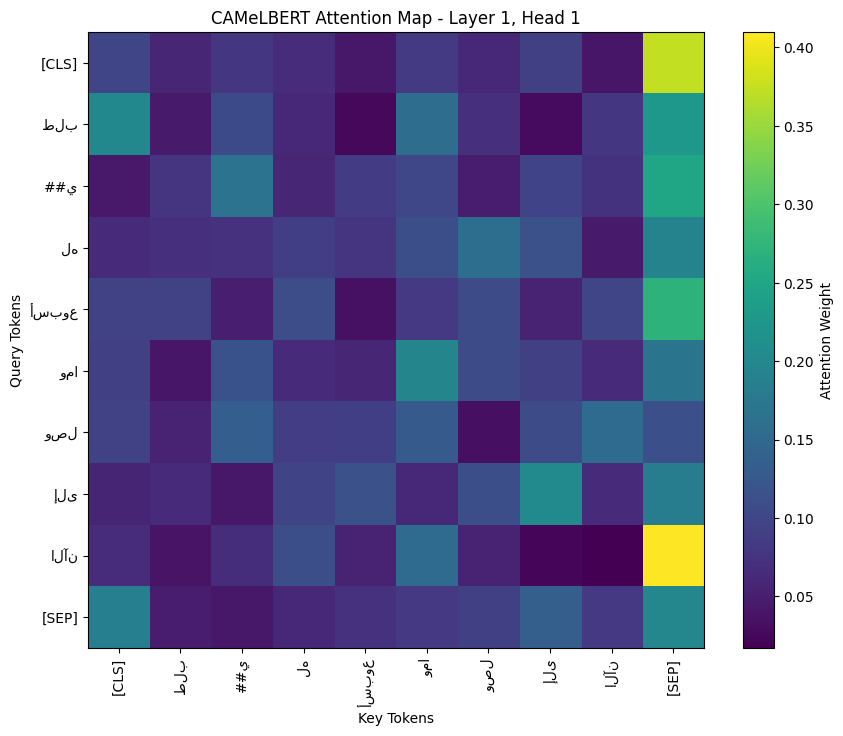

In [61]:
import matplotlib.pyplot as plt

# First attention layer and first attention head
attention = outputs.attentions[0][0, 0].detach().numpy()

plt.figure(figsize=(10, 8))
plt.imshow(attention)

plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)

plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("CAMeLBERT Attention Map - Layer 1, Head 1")

plt.colorbar(label="Attention Weight")
plt.show()

# 3

## Customer Issue Classification

Train CAMeLBERT to classify Arabic customer messages into four issue categories: delivery, payment, return/refund, and technical issues.

In [62]:
label_map = {
    "delivery": 0,
    "payment": 1,
    "return_refund": 2,
    "technical": 3
}

df["label"] = df["issue_type"].map(label_map)

df[["text", "issue_type", "label"]].head(10)

,text,issue_type,label
0,طلبي له أسبوع وما وصل إلى الآن,delivery,0
1,وين طلبي؟ للحين ما وصلني,delivery,0
2,تأخر توصيل الطلب عن الموعد المحدد,delivery,0
3,الطلب ما وصل في الوقت المتوقع,delivery,0
4,متى راح يوصل طلبي؟,delivery,0
5,صار لي عشرة أيام أنتظر الطلب,delivery,0
6,حالة الطلب تظهر أنه ما زال قيد التوصيل,delivery,0
7,المندوب ما وصل إلى الآن,delivery,0
8,موعد التوصيل كان أمس وما وصل شيء,delivery,0
9,أريد معرفة حالة الشحنة,delivery,0


### Train-Test Split



In [63]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

Training samples: 64
Testing samples: 16


### Tokenize Training and Testing Data

Tokenize the training and testing messages using CAMeLBERT and prepare them as model inputs.

In [64]:
def tokenize_data(data):
    return tokenizer(
        data["text"].tolist(),
        padding="max_length",
        truncation=True,
        max_length=12,
        return_tensors="pt"
    )

train_tokens = tokenize_data(train_df)
test_tokens = tokenize_data(test_df)

In [65]:
train_tokens["labels"] = torch.tensor(
    train_df["label"].tolist()
)

test_tokens["labels"] = torch.tensor(
    test_df["label"].tolist()
)

In [66]:
print("Train input shape:", train_tokens["input_ids"].shape)
print("Test input shape:", test_tokens["input_ids"].shape)
print("Train labels shape:", train_tokens["labels"].shape)

Train input shape: torch.Size([64, 12])
Test input shape: torch.Size([16, 12])
Train labels shape: torch.Size([64])


### Create PyTorch Datasets

Convert the tokenized training and testing data into PyTorch datasets so they can be used for model training and evaluation.

In [67]:
from torch.utils.data import Dataset

class CustomerIssueDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        return {
            key: value[idx]
            for key, value in self.encodings.items()
        }

train_dataset = CustomerIssueDataset(train_tokens)
test_dataset = CustomerIssueDataset(test_tokens)

In [68]:
print("Train Dataset:", len(train_dataset))
print("Test Dataset:", len(test_dataset))

Train Dataset: 64
Test Dataset: 16


### Load CAMeLBERT for Classification

Load CAMeLBERT as a sequence classification model and configure it to classify customer messages into four issue categories.

In [69]:
from transformers import AutoModelForSequenceClassification

classification_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4
)

classification_model.config.id2label = {
    0: "delivery",
    1: "payment",
    2: "return_refund",
    3: "technical"
}

classification_model.config.label2id = {
    "delivery": 0,
    "payment": 1,
    "return_refund": 2,
    "technical": 3
}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-mix
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSIN

### Evaluation Metrics



In [70]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }

### Model Training

In [72]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./customer_support_model",
    num_train_epochs=8,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=5,
    report_to="none"
)

trainer = Trainer(
    model=classification_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [73]:
trainer.train()

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
5,1.480760
10,1.308517
15,1.214782
20,1.077555
25,0.932551
30,0.821784
35,0.772809
40,0.580521
45,0.565704
50,0.469861


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=64, training_loss=0.8105176128447056, metrics={'train_runtime': 149.8096, 'train_samples_per_second': 3.418, 'train_steps_per_second': 0.427, 'total_flos': 3157389361152.0, 'train_loss': 0.8105176128447056, 'epoch': 8.0})

In [74]:
evaluation_results = trainer.evaluate()
evaluation_results

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step,Accuracy,Macro F1
0.431137,0.728418,64,0.750000,0.711111


{'eval_loss': 0.7284184098243713,
 'eval_accuracy': 0.75,
 'eval_macro_f1': 0.711111111111111}

### Prediction Analysis

Compare the model predictions with the actual labels to identify correctly and incorrectly classified customer messages.

In [75]:
predictions = trainer.predict(test_dataset)

predicted_labels = np.argmax(
    predictions.predictions,
    axis=1
)

id_to_label = {
    0: "delivery",
    1: "payment",
    2: "return_refund",
    3: "technical"
}

results = pd.DataFrame({
    "text": test_df["text"],
    "actual": [
        id_to_label[label]
        for label in test_df["label"]
    ],
    "predicted": [
        id_to_label[label]
        for label in predicted_labels
    ]
})

results["correct"] = (
    results["actual"] == results["predicted"]
)

results

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,text,actual,predicted,correct
0,تظهر شاشة بيضاء لما أفتح التطبيق,technical,technical,True
1,كل ما أسجل الدخول يطلعني من الحساب,technical,technical,True
2,طلبي متأخر وأحتاج أعرف وين وصل,delivery,delivery,True
3,المبلغ انخصم من البنك والطلب ما تسجل,payment,payment,True
4,حالة الطلب تظهر أنه ما زال قيد التوصيل,delivery,delivery,True
5,نسيت كلمة المرور وما قدرت أدخل حسابي,technical,technical,True
6,الدفع ما يقبل بطاقتي,payment,payment,True
7,أبي ألغي الطلب وأسترجع فلوسي,return_refund,delivery,False
8,ما أقدر أنشئ حساب جديد,technical,technical,True
9,طلبت استرجاع المبلغ وما وصلني,return_refund,payment,False


### Confusion Matrix

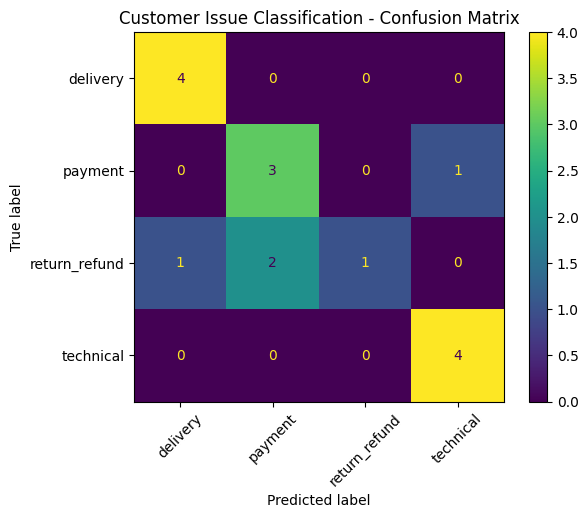

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = [
    "delivery",
    "payment",
    "return_refund",
    "technical"
]

cm = confusion_matrix(
    results["actual"],
    results["predicted"],
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Customer Issue Classification - Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

## Named Entity Recognition (NER) and Subword Alignment

In [78]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "CAMeL-Lab/bert-base-arabic-camelbert-mix"
)

words = ["طلبت", "سماعة", "أمازون"]

labels = ["O", "B-PRODUCT", "B-COMPANY"]

tokens = tokenizer(
    words,
    is_split_into_words=True
)

print("Tokens:")
print(tokenizer.convert_ids_to_tokens(tokens["input_ids"]))

print("Word IDs:")
print(tokens.word_ids())

Tokens:
['[CLS]', 'طلبت', 'سماع', '##ة', 'أما', '##زون', '[SEP]']
Word IDs:
[None, 0, 1, 1, 2, 2, None]


### Word ID Mapping

In [79]:
word_ids = tokens.word_ids()

for token, word_id in zip(
    tokenizer.convert_ids_to_tokens(tokens["input_ids"]),
    word_ids
):
    print(token, "→", word_id)

[CLS] → None
طلبت → 0
سماع → 1
##ة → 1
أما → 2
##زون → 2
[SEP] → None


### First and Continuation Subwords

In [80]:
for token, word_id in zip(
    tokenizer.convert_ids_to_tokens(tokens["input_ids"]),
    tokens.word_ids()
):
    if word_id is not None:
        print(token, "→ Word", word_id)

طلبت → Word 0
سماع → Word 1
##ة → Word 1
أما → Word 2
##زون → Word 2


### Arabic Clitic Splitting

In [81]:
words = ["وبطاقتي", "بالتطبيق", "والطلب"]

tokens = tokenizer(
    words,
    is_split_into_words=True
)

print("Tokens:")
print(tokenizer.convert_ids_to_tokens(tokens["input_ids"]))

print("Word IDs:")
print(tokens.word_ids())

Tokens:
['[CLS]', 'وبط', '##اق', '##تي', 'بالت', '##طبيق', 'والطلب', '[SEP]']
Word IDs:
[None, 0, 0, 0, 1, 1, 2, None]


### Alignment Tests

In [82]:
tests = [
    ("طلبت سماعة", ["O", "B-PRODUCT"]),
    ("اشتريت آيفون", ["O", "B-PRODUCT"]),
    ("الطلب من أمازون", ["O", "O", "B-COMPANY"]),
    ("الشحنة مع سمسا", ["O", "O", "B-COMPANY"]),
    ("دفعت بمدى", ["O", "B-PAYMENT"]),
    ("استخدمت فيزا", ["O", "B-PAYMENT"]),
    ("اشتريت لابتوب", ["O", "B-PRODUCT"]),
    ("الطلب من نون", ["O", "O", "B-COMPANY"])
]

print("Tests:", len(tests), "/ 8")

Tests: 8 / 8


### Subword-Level NER Evaluation

In [83]:
tokens_list = tokenizer.convert_ids_to_tokens(
    tokens["input_ids"]
)

word_ids = tokens.word_ids()

for token, word_id in zip(tokens_list, word_ids):
    print(token, "→", word_id)

[CLS] → None
وبط → 0
##اق → 0
##تي → 0
بالت → 1
##طبيق → 1
والطلب → 2
[SEP] → None


# 4
## Dialect Robustness and Detection

In [84]:
dialect_words = [
    "ابي",
    "ابغى",
    "وش",
    "وين",
    "ليش",
    "للحين",
    "مو"
]

def detect_dialect(text):
    for word in dialect_words:
        if word in text:
            return "Dialect"
    return "MSA"

In [85]:
samples = [
    "أريد معرفة حالة طلبي",
    "وين طلبي للحين ما وصل",
    "تم خصم المبلغ مرتين من حسابي",
    "ليش انخصم مني المبلغ مرتين",
    "أريد إرجاع المنتج",
    "ابي ارجع المنتج"
]

for text in samples:
    print(text, "→", detect_dialect(text))

أريد معرفة حالة طلبي → MSA
وين طلبي للحين ما وصل → Dialect
تم خصم المبلغ مرتين من حسابي → Dialect
ليش انخصم مني المبلغ مرتين → Dialect
أريد إرجاع المنتج → MSA
ابي ارجع المنتج → Dialect


In [88]:
import re

def normalize_arabic(text):
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ة", "ه", text)
    text = re.sub(r"  ", " ", text)
    return text

text = "أريد  إرجاع الطلب إلى المتجر"

print("Before:", text)
print("After :", normalize_arabic(text))

Before: أريد  إرجاع الطلب إلى المتجر
After : اريد ارجاع الطلب الي المتجر


In [89]:
texts = [
    "أريد معرفة حالة طلبي",
    "وين طلبي للحين ما وصل؟",
    "ليش انخصم مني المبلغ مرتين؟"
]

for text in texts:
    print(text)

أريد معرفة حالة طلبي
وين طلبي للحين ما وصل؟
ليش انخصم مني المبلغ مرتين؟


In [90]:
text = "وبالطلب"

print("Original:", text)
print("Segmented: و + ب + ال + طلب")

Original: وبالطلب
Segmented: و + ب + ال + طلب


### Dialect-Aware Fine-tuning

In [91]:
dialect_data = {
    "text": [
        # Delivery
        "وين طلبي للحين ما وصل",
        "طلبي تأخر مره وش السالفه",
        "المندوب للحين ما جاني",
        "شحنتي وينها صار لها كم يوم",

        # Payment
        "ليش انخصم مني المبلغ مرتين",
        "بطاقتي مو راضيه تقبل الدفع",
        "دفعت بس الطلب ما تأكد",
        "كل ما احاول ادفع العمليه تفشل",

        # Return / Refund
        "ابي ارجع المنتج واسترد فلوسي",
        "رجعت الطلب وللحين ما رجعت فلوسي",
        "ابي الغي الطلب وترجعون المبلغ",
        "متى ترجع فلوسي بعد الاسترجاع",

        # Technical
        "التطبيق مو راضي يفتح",
        "ما اقدر ادخل على حسابي",
        "نسيت الباسورد وما قدرت ادخل",
        "التطبيق يعلق علي كل شوي"
    ],

    "issue_type": [
        "delivery", "delivery", "delivery", "delivery",
        "payment", "payment", "payment", "payment",
        "return_refund", "return_refund", "return_refund", "return_refund",
        "technical", "technical", "technical", "technical"
    ]
}

dialect_df = pd.DataFrame(dialect_data)

dialect_df["label"] = dialect_df["issue_type"].map(label_map)

dialect_df

,text,issue_type,label
0,وين طلبي للحين ما وصل,delivery,0
1,طلبي تأخر مره وش السالفه,delivery,0
2,المندوب للحين ما جاني,delivery,0
3,شحنتي وينها صار لها كم يوم,delivery,0
4,ليش انخصم مني المبلغ مرتين,payment,1
5,بطاقتي مو راضيه تقبل الدفع,payment,1
6,دفعت بس الطلب ما تأكد,payment,1
7,كل ما احاول ادفع العمليه تفشل,payment,1
8,ابي ارجع المنتج واسترد فلوسي,return_refund,2
9,رجعت الطلب وللحين ما رجعت فلوسي,return_refund,2


In [92]:
augmented_train_df = pd.concat(
    [train_df, dialect_df],
    ignore_index=True
)

print("Original Training Samples:", len(train_df))
print("Dialect Samples:", len(dialect_df))
print("Augmented Training Samples:", len(augmented_train_df))
print("Testing Samples:", len(test_df))

Original Training Samples: 64
Dialect Samples: 16
Augmented Training Samples: 80
Testing Samples: 16


In [93]:
augmented_train_tokens = tokenize_data(augmented_train_df)

augmented_train_tokens["labels"] = torch.tensor(
    augmented_train_df["label"].tolist()
)

augmented_train_dataset = CustomerIssueDataset(
    augmented_train_tokens
)

print("Augmented Train Dataset:", len(augmented_train_dataset))

Augmented Train Dataset: 80


In [94]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# Load a fresh CAMeLBERT model
dialect_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4
)

# Training configuration
dialect_training_args = TrainingArguments(
    output_dir="./dialect_customer_support_model",
    num_train_epochs=8,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=5,
    report_to="none"
)

# Create Trainer
dialect_trainer = Trainer(
    model=dialect_model,
    args=dialect_training_args,
    train_dataset=augmented_train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Train the model
dialect_trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-mix
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSIN

Step,Training Loss
5,1.398454
10,1.425761
15,1.214194
20,1.162365
25,0.928677
30,0.877212
35,0.639157
40,0.634878
45,0.463944
50,0.410021


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=80, training_loss=0.6607666417956353, metrics={'train_runtime': 202.6134, 'train_samples_per_second': 3.159, 'train_steps_per_second': 0.395, 'total_flos': 3946736701440.0, 'train_loss': 0.6607666417956353, 'epoch': 8.0})

In [95]:
dialect_results = dialect_trainer.evaluate()

dialect_results

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step,Accuracy,Macro F1
0.183742,0.323219,80,0.875000,0.861111


{'eval_loss': 0.32321882247924805,
 'eval_accuracy': 0.875,
 'eval_macro_f1': 0.861111111111111}

# 5
## Semantic Search for Customer Support Solutions

In [96]:
solutions = [
    "إذا تأخر الطلب، يمكنك متابعة حالة الشحنة من صفحة طلباتي والتحقق من آخر تحديث للتوصيل.",
    "إذا ظهر أن الطلب تم توصيله ولم تستلمه، يرجى التواصل مع خدمة العملاء للتحقق من حالة التسليم.",
    "يمكن تعديل عنوان التوصيل قبل شحن الطلب من خلال تفاصيل الطلب.",

    "إذا تم خصم المبلغ مرتين، يرجى التحقق من العمليات البنكية والتواصل مع خدمة العملاء لاسترداد المبلغ المكرر.",
    "إذا فشلت عملية الدفع، تحقق من بيانات البطاقة والرصيد ثم حاول مرة أخرى.",
    "إذا تم خصم المبلغ ولم يتم تأكيد الطلب، يرجى الانتظار والتحقق من حالة العملية قبل إعادة الدفع.",

    "يمكن إرجاع المنتج من خلال صفحة طلباتي واختيار طلب الإرجاع.",
    "بعد قبول طلب الاسترجاع، قد يستغرق استرداد المبلغ عدة أيام حسب وسيلة الدفع.",
    "إذا وصل المنتج تالفًا أو غير مطابق، يمكنك تقديم طلب إرجاع أو استبدال.",

    "إذا تعذر تسجيل الدخول، حاول إعادة تعيين كلمة المرور من صفحة تسجيل الدخول.",
    "إذا لم يصلك رمز التحقق، تأكد من رقم الجوال وحاول طلب رمز جديد.",
    "إذا كان التطبيق لا يعمل، حاول إغلاقه وإعادة تشغيله أو تحديثه إلى أحدث إصدار."
]

print("Number of solutions:", len(solutions))

Number of solutions: 12


### Solution Embeddings

In [97]:
from sentence_transformers import SentenceTransformer

search_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

solution_embeddings = search_model.encode(solutions)

print("Embeddings Shape:", solution_embeddings.shape)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings Shape: (12, 384)


### FAISS Index

In [100]:
# Normalize solution embeddings
solution_embeddings = search_model.encode(
    solutions,
    normalize_embeddings=True
)

dimension = solution_embeddings.shape[1]

# Inner Product on normalized vectors = Cosine Similarity
index = faiss.IndexFlatIP(dimension)
index.add(solution_embeddings)

print("Number of indexed solutions:", index.ntotal)

Number of indexed solutions: 12


### Semantic Search

In [103]:
query = "طلبي للحين ما وصل"

# Convert the customer message into an embedding

query_embedding = search_model.encode(
    [query],
    normalize_embeddings=True
)

# Search for the closest solution
distances, indices = index.search(query_embedding, 1)

best_solution = solutions[indices[0][0]]

print("Customer Message:", query)
print("\nSuggested Solution:")
print(best_solution)

Customer Message: طلبي للحين ما وصل

Suggested Solution:
إذا ظهر أن الطلب تم توصيله ولم تستلمه، يرجى التواصل مع خدمة العملاء للتحقق من حالة التسليم.


### Recall@10 and MRR@10

In [104]:
results = [
    "إذا ظهر أن الطلب تم توصيله ولم تستلمه، يرجى التواصل مع خدمة العملاء للتحقق من حالة التسليم.",
    "إذا تأخر الطلب، يمكنك متابعة حالة الشحنة من صفحة طلباتي والتحقق من آخر تحديث للتوصيل.",
    "يمكن تعديل عنوان التوصيل قبل شحن الطلب من خلال تفاصيل الطلب."
]

correct_answer = "إذا تأخر الطلب، يمكنك متابعة حالة الشحنة من صفحة طلباتي والتحقق من آخر تحديث للتوصيل."

rank = results.index(correct_answer) + 1

recall_at_10 = 1 if rank <= 10 else 0
mrr_at_10 = 1 / rank

print("Rank:", rank)
print("Recall@10:", recall_at_10)
print("MRR@10:", mrr_at_10)

Rank: 2
Recall@10: 1
MRR@10: 0.5


### Cross-Encoder Re-ranking

In [105]:
from sentence_transformers import CrossEncoder

query = "طلبي للحين ما وصل"

results = [
    "إذا ظهر أن الطلب تم توصيله ولم تستلمه، يرجى التواصل مع خدمة العملاء للتحقق من حالة التسليم.",
    "إذا تأخر الطلب، يمكنك متابعة حالة الشحنة من صفحة طلباتي والتحقق من آخر تحديث للتوصيل.",
    "يمكن تعديل عنوان التوصيل قبل شحن الطلب من خلال تفاصيل الطلب."
]

reranker = CrossEncoder(
    "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1"
)

pairs = [[query, text] for text in results]

scores = reranker.predict(pairs)

for text, score in zip(results, scores):
    print(round(float(score), 2), "→", text)

config.json:   0%|          | 0.00/891 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

-4.31 → إذا ظهر أن الطلب تم توصيله ولم تستلمه، يرجى التواصل مع خدمة العملاء للتحقق من حالة التسليم.
-5.9 → إذا تأخر الطلب، يمكنك متابعة حالة الشحنة من صفحة طلباتي والتحقق من آخر تحديث للتوصيل.
-6.4 → يمكن تعديل عنوان التوصيل قبل شحن الطلب من خلال تفاصيل الطلب.


### Cross-Lingual and No-Answer Evaluation

In [109]:
queries = [
    "طلبي للحين ما وصل",
    "My order has not arrived yet",
    "ما أقدر أدخل على حسابي ونسيت كلمة المرور"
]

for query in queries:

    q_emb = search_model.encode(
        [query],
        normalize_embeddings=True
    )

    scores, indices = index.search(q_emb, 1)

    print("Query:", query)
    print("Result:", solutions[indices[0][0]])
    print("-" * 50)

Query: طلبي للحين ما وصل
Result: إذا ظهر أن الطلب تم توصيله ولم تستلمه، يرجى التواصل مع خدمة العملاء للتحقق من حالة التسليم.
--------------------------------------------------
Query: My order has not arrived yet
Result: إذا ظهر أن الطلب تم توصيله ولم تستلمه، يرجى التواصل مع خدمة العملاء للتحقق من حالة التسليم.
--------------------------------------------------
Query: ما أقدر أدخل على حسابي ونسيت كلمة المرور
Result: إذا لم يصلك رمز التحقق، تأكد من رقم الجوال وحاول طلب رمز جديد.
--------------------------------------------------


 Final Evaluation

In [110]:
customer_messages = [
    {
        "language": "Arabic",
        "dialect": "Saudi",
        "length": "Short",
        "correct": 1
    },
    {
        "language": "Arabic",
        "dialect": "Saudi",
        "length": "Long",
        "correct": 1
    },
    {
        "language": "Arabic",
        "dialect": "MSA",
        "length": "Short",
        "correct": 1
    },
    {
        "language": "English",
        "dialect": "Standard",
        "length": "Short",
        "correct": 1
    },
    {
        "language": "English",
        "dialect": "Standard",
        "length": "Long",
        "correct": 0
    }
]

for message in customer_messages:
    print(
        message["language"],
        "|", message["dialect"],
        "|", message["length"],
        "| Correct:", message["correct"]
    )

Arabic | Saudi | Short | Correct: 1
Arabic | Saudi | Long | Correct: 1
Arabic | MSA | Short | Correct: 1
English | Standard | Short | Correct: 1
English | Standard | Long | Correct: 0


### Bootstrap Confidence Interval

In [111]:
import numpy as np
from sklearn.metrics import accuracy_score

y_true = test_df["label"].to_numpy()
y_pred = predicted_labels

scores = []

for _ in range(1000):
    i = np.random.choice(
        len(y_true),
        len(y_true),
        replace=True
    )

    scores.append(
        accuracy_score(y_true[i], y_pred[i])
    )

lower = np.percentile(scores, 2.5)
upper = np.percentile(scores, 97.5)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("95% CI:", lower, "-", upper)

Accuracy: 0.75
95% CI: 0.5625 - 0.9375


### Error Analysis and Error Taxonomy

In [112]:
errors = [
    ("طلبي للحين ما وصل", "Correct prediction"),
    ("رجعت المنتج وللحين ما رجع المبلغ", "Incorrect prediction"),
    ("هل عندكم خصم للطلاب؟", "No suitable answer")
]

for text, error in errors:
    print(text, "→", error)

طلبي للحين ما وصل → Correct prediction
رجعت المنتج وللحين ما رجع المبلغ → Incorrect prediction
هل عندكم خصم للطلاب؟ → No suitable answer
